# 05 - Dynamic Parameters and Subroutines with tProc v2

**Objective:** Learn how to modify pulse parameters dynamically in real-time (virtual-Z gates, phase updates) and use subroutines for efficient code reuse on the tProc.

## 1. Setup

In [ ]:
# Standard imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import logging

from qick import *
from qick.asm_v2 import AveragerProgramV2, AsmV2

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# Connect to the board (adjust the path to your firmware)
BITSTREAM_PATH = '/path/to/your/firmware.bit'  # <--- CHANGE THIS
soc = QickSoc(BITSTREAM_PATH)
soccfg = soc

# Define hardware channels
GEN_CH = 0
RO_CH = 0

## 2. Understanding Dynamic Parameter Updates

In tProc v2, pulse parameters are stored in **waveform memory**. Each pulse consists of one or more waveforms (for flat-top pulses: rise, flat, fall). You can:
- **Read** a waveform from memory into waveform registers
- **Modify** parameters in the registers (frequency, phase, gain, length)
- **Write** the modified waveform back to memory

This allows you to change pulse properties on-the-fly without recompiling the program.

**Key operations:**
- `read_wmem(name)` - Read a waveform into registers
- `write_wmem(name)` - Write registers back to waveform memory
- Waveform registers: `w_freq`, `w_phase`, `w_gain`, `w_length`, `w_env`, `w_conf`

## 3. Virtual-Z Gate: Updating Phase Dynamically

A virtual-Z gate is a phase update applied to subsequent pulses without playing an actual pulse. This is essential for many quantum control sequences.

  0%|          | 0/10 [00:00<?, ?it/s]

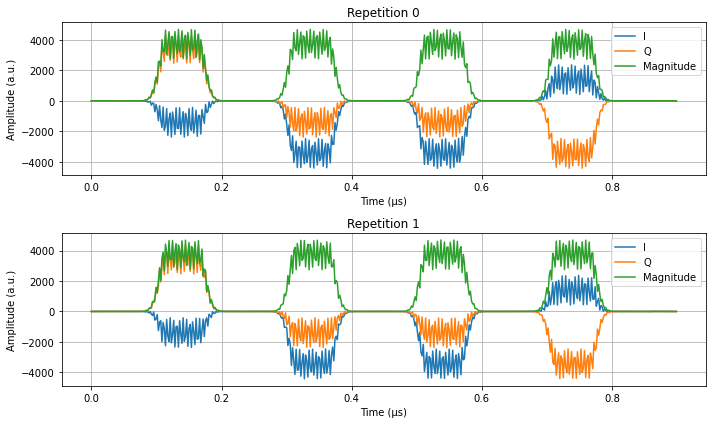


=== Virtual-Z Subroutine ASM ===
     NOP 
     REG_WR s12 imm #0 
     WPORT_WR p2 wmem [&3] @0 
     TIME #492 inc_ref 
     REG_WR r0 imm #0 
reps:
     TRIG p0 set @123 
     TRIG p3 set @123 
     TRIG p4 set @123 
     TRIG p0 clr @133 
     TRIG p3 clr @133 
     TRIG p4 clr @133 
     WPORT_WR p0 wmem [&0] @0 
     WPORT_WR p0 wmem [&1] @0 
     WPORT_WR p0 wmem [&2] @0 
     REG_WR s15 label virtual_z 
     CALL [s15] 
     WPORT_WR p0 wmem [&0] @98 
     WPORT_WR p0 wmem [&1] @98 
     WPORT_WR p0 wmem [&2] @98 
     WPORT_WR p0 wmem [&0] @197 
     WPORT_WR p0 wmem [&1] @197 
     WPORT_WR p0 wmem [&2] @197 
     REG_WR s15 label virtual_z 
     CALL [s15] 
     WPORT_WR p0 wmem [&0] @295 
     WPORT_WR p0 wmem [&1] @295 
     WPORT_WR p0 wmem [&2] @295 
     REG_WR r_wave wmem [&0] 
     REG_WR w1 imm #0 
     WMEM_WR &0 
     REG_WR r_wave wmem [&1] 
     REG_WR w1 imm #0 
     WMEM_WR &1 
     REG_WR r_wave wmem [&2] 
     REG_WR w1 imm #0 
     WMEM_WR &2 
     REG_WR s

In [14]:
class VirtualZProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        # Define a Gaussian envelope for pulse shaping
        ramp_len = 0.1
        self.add_gauss(ch=gen_ch, name="ramp", 
                       sigma=ramp_len/10, 
                       length=ramp_len, 
                       even_length=True)
        
        # Define a flat-top pulse (has 3 waveforms: rise, flat, fall)
        self.add_pulse(ch=gen_ch, name="my_pulse", 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       length=0.05,
                       phase=0,
                       gain=1.0)

        # Create a subroutine for virtual-Z (90-degree phase rotation)
        sub = AsmV2()
        for wname in self.list_pulse_waveforms("my_pulse"):
            sub.read_wmem(name=wname)
            sub.inc_reg(dst='w_phase', src=self.deg2reg(90, gen_ch=gen_ch))
            sub.write_wmem(name=wname)
        self.add_subroutine("virtual_z", sub)

        # Configure readout
        self.add_readoutconfig(ch=ro_ch, name="my_ro", 
                               freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name="my_ro", t=0)
        
    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        # Pulse 1: phase = 0
        self.pulse(ch=cfg['gen_ch'], name="my_pulse", t=0, tag='pulse1')
        
        # Apply virtual-Z (adds 90° to subsequent pulses)
        self.call("virtual_z")
        
        # Pulse 2: phase = 90°
        self.pulse(ch=cfg['gen_ch'], name="my_pulse", t=0.2, tag='pulse2')
        
        # Pulse 3: phase = 90° (same as pulse 2)
        self.pulse(ch=cfg['gen_ch'], name="my_pulse", t=0.4, tag='pulse3')
        
        # Apply another virtual-Z (adds another 90° → total 180°)
        self.call("virtual_z")
        
        # Pulse 4: phase = 180°
        self.pulse(ch=cfg['gen_ch'], name="my_pulse", t=0.6, tag='pulse4')
        
        # Reset phase to 0 for next shot
        for wname in self.list_pulse_waveforms("my_pulse"):
            self.read_wmem(name=wname)
            self.write_reg(dst='w_phase', src=0)
            self.write_wmem(name=wname)

# Configuration
config_vz = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100,
    'trig_time': 0.25,
    'ro_len': 0.9
}

# Run the program
prog = VirtualZProgram(soccfg, reps=2, final_delay=0.5, cfg=config_vz)
iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

# Plot results for each repetition
fig, axes = plt.subplots(len(iq_data[0]), 1, figsize=(10, 6))
if len(iq_data[0]) == 1:
    axes = [axes]

for rep, iq in enumerate(iq_data[0]):
    ax = axes[rep]
    ax.plot(time_axis, iq[:,0], label='I')
    ax.plot(time_axis, iq[:,1], label='Q')
    ax.plot(time_axis, np.abs(iq.dot([1,1j])), label='Magnitude')
    ax.legend()
    ax.set_title(f"Repetition {rep}")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.set_xlabel("Time (µs)")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Inspect the subroutine in the compiled program
print("\n=== Virtual-Z Subroutine ASM ===")
print(prog.asm())

**Explanation:**
- The virtual-Z subroutine reads each waveform, adds 90° to its phase, and writes it back
- `deg2reg()` converts degrees to the tProc's internal phase units
- After the sequence, we reset the phase to 0 for the next shot
- Subroutines are defined using `AsmV2()` and added with `add_subroutine()`
- Called with `call("name")`
- Use `asm_subroutine()` to see the generated assembly for a subroutine

## 4. Understanding Waveform Structure

Different pulse styles have different waveform counts:
- `const` - 1 waveform
- `arb` (arbitrary/envelope) - 1 waveform
- `flat_top` - 3 waveforms (rise, flat, fall)

You can list waveforms for any pulse:

In [15]:
print("Waveforms for 'my_pulse':")
for wname in prog.list_pulse_waveforms("my_pulse"):
    print(f"  {wname}")

# You can also inspect parameters of individual waveforms
waveform = prog.pulses['my_pulse'].waveforms[0]
print(f"\nFirst waveform parameters: {waveform.__dict__}")

Waveforms for 'my_pulse':
  my_pulse_w0
  my_pulse_w1
  my_pulse_w2

First waveform parameters: {'freq': QickRawParam(par='freq', start=54613333, spans={}, quantize=1, steps={}), 'phase': QickRawParam(par='phase', start=0, spans={}, quantize=1, steps={}), 'env': 0, 'gain': QickRawParam(par='gain', start=32766, spans={}, quantize=2, steps={}), 'length': 25, 'conf': 8, 'name': 'my_pulse_w0'}


## 5. Subroutines for Code Reuse

Subroutines are useful for code that repeats across multiple places in your program. They can be called multiple times.

In [17]:
class SubroutineExampleProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Define a simple pulse
        self.add_pulse(ch=cfg['gen_ch'], name="test_pulse", 
                       style="const", 
                       freq=cfg['freq'], length=0.1,
                       phase=0, gain=1.0)

        # Define a subroutine that plays a pulse sequence
        sub = AsmV2()
        sub.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)
        sub.delay(0.15)
        sub.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)
        self.add_subroutine("pulse_pair", sub)

        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro", 
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)
        
    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        
        # Call the subroutine multiple times
        self.call("pulse_pair")   # First pair
        self.delay(0.2)
        self.call("pulse_pair")   # Second pair

config_sub = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 100,
    'trig_time': 0.25,
    'ro_len': 1.5
}

prog = SubroutineExampleProgram(soccfg, reps=1, final_delay=0.5, cfg=config_sub)

print("=== Subroutine macro_list ===")
for inst in prog.subroutines['pulse_pair'].macro_list:
    print(inst)

print("\n=== Fully compiled program ===")
print(prog.asm())

=== Subroutine macro_list ===
Pulse(ch=0, name='test_pulse', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0xffff4c333a30>}, t_regs={'t': 0})
Delay(t=0.15, auto=False, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0xffff4c332410>}, t_regs={'t': 74})
Pulse(ch=0, name='test_pulse', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0xffff4c3338e0>}, t_regs={'t': 0})

=== Programa completo compilado ===
     NOP 
     REG_WR s12 imm #0 
     WPORT_WR p2 wmem [&1] @0 
     TIME #492 inc_ref 
     REG_WR r0 imm #0 
reps:
     TRIG p0 set @123 
     TRIG p4 set @123 
     TRIG p0 clr @133 
     TRIG p4 clr @133 
     REG_WR s15 label pulse_pair 
     CALL [s15] 
     TIME #98 inc_ref 
     REG_WR s15 label pulse_pair 
     CALL [s15] 
     REG_WR s15 label SKIP 
     WAIT [s15] @762 time 
     TIME #1008 inc_ref 
     REG_WR s12 op -op(s12 + #1) 
     REG_WR s15 label reps 
     TEST -op(r0 - #0) 
     JUMP [s15] -if(NZ) -wr(r0 op) -op(r0 + #1) 
     

**Benefits of subroutines:**
- Reduce program size (important since program memory is limited to 4096 words)
- Make code more readable and maintainable
- Allow complex sequences to be built from reusable components

**Limitation:** The timeline management code doesn't understand jumps. If your subroutine contains timed instructions, ensure the timeline is consistent before and after the call. For simple pulse sequences without timeline dependencies, subroutines work well.

## 6. Dynamic Gain Modulation

You can also update gain dynamically to implement amplitude modulation.

  0%|          | 0/10 [00:00<?, ?it/s]

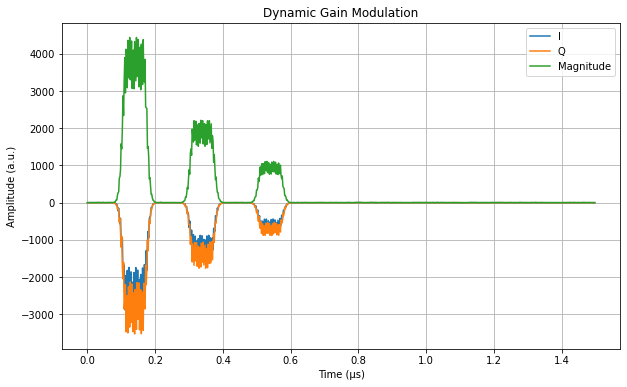

In [20]:
class GainModulationProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])
        
        # Define a Gaussian envelope
        ramp_len = 0.1
        self.add_gauss(ch=cfg['gen_ch'], name="ramp", 
                       sigma=ramp_len/10, length=ramp_len, even_length=True)
        
        # Define three pulses with different gains
        self.add_pulse(ch=cfg['gen_ch'], name="pulse_full", 
                       style="flat_top", envelope="ramp",
                       freq=cfg['freq'], length=0.05, phase=0, gain=1.0)
        
        self.add_pulse(ch=cfg['gen_ch'], name="pulse_half", 
                       style="flat_top", envelope="ramp",
                       freq=cfg['freq'], length=0.05, phase=0, gain=0.5)
        
        self.add_pulse(ch=cfg['gen_ch'], name="pulse_quarter", 
                       style="flat_top", envelope="ramp",
                       freq=cfg['freq'], length=0.05, phase=0, gain=0.25)
        
        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro", 
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)
        
    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        
        # Pulse with full gain
        self.pulse(ch=cfg['gen_ch'], name="pulse_full", t=0, tag='pulse_full')
        
        # Pulse with half gain
        self.pulse(ch=cfg['gen_ch'], name="pulse_half", t=0.2, tag='pulse_half')
        
        # Pulse with quarter gain
        self.pulse(ch=cfg['gen_ch'], name="pulse_quarter", t=0.4, tag='pulse_quarter')


prog = GainModulationProgram(soccfg, reps=1, final_delay=0.5, cfg=config_sub)
iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

plt.figure(figsize=(10, 6))
plt.plot(time_axis, iq_data[0][:,0], label='I')
plt.plot(time_axis, iq_data[0][:,1], label='Q')
plt.plot(time_axis, np.abs(iq_data[0].dot([1,1j])), label='Magnitude')
plt.legend()
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Dynamic Gain Modulation')
plt.grid(True)
plt.show()

**Note on gain operations:**
- Gain is stored as a 16-bit integer (0-32766 for full scale)
- Shifting right (>>) divides by 2
- Shifting left (<<) multiplies by 2
- Be careful not to exceed the maximum value (32766)
- Use `reg_op()` for arithmetic operations on registers

## 7. Inspecting Waveform Memory

You can inspect the contents of waveform memory for debugging.

In [25]:
# Print all defined pulses after program execution
print("All defined pulses:")
for pulse_name, pulse_obj in prog.pulses.items():
    print(f"\nPulse: {pulse_name}")
    print(f"  type: {type(pulse_obj)}")
    print(f"  waveforms: {pulse_obj.waveforms}")
    for waveform in pulse_obj.waveforms:
        print(f"  waveform: {waveform}")
        print(f"    attributes: {[a for a in dir(waveform) if not a.startswith('_')]}")

# You can also read waveform memory from the board
# This requires knowing the waveform addresses
# waddr = prog.pulse_waveform_addrs['my_pulse']['my_pulse_w0']
# waveform_data = soc.read_mem(length=100, mem_sel='wmem', addr=waddr)
# Note: read_mem returns data as 32-bit integers; you may need to reinterpret as 16-bit I/Q pairs

All defined pulses:

Pulse: pulse_full
  type: <class 'qick.asm_v2.QickPulse'>
  waveforms: [Waveform(name='pulse_full_w0', freq=QickRawParam(par='freq', start=54613333, spans={}, quantize=1, steps={}), phase=QickRawParam(par='phase', start=0, spans={}, quantize=1, steps={}), env=0, gain=QickRawParam(par='gain', start=32766, spans={}, quantize=2, steps={}), length=25, conf=8), Waveform(name='pulse_full_w1', freq=QickRawParam(par='freq', start=54613333, spans={}, quantize=1, steps={}), phase=QickRawParam(par='phase', start=0, spans={}, quantize=1, steps={}), env=0, gain=QickRawParam(par='gain', start=16383, spans={}, quantize=1, steps={}), length=QickRawParam(par='length', start=25, spans={}, quantize=1, steps={}), conf=9), Waveform(name='pulse_full_w2', freq=QickRawParam(par='freq', start=54613333, spans={}, quantize=1, steps={}), phase=QickRawParam(par='phase', start=0, spans={}, quantize=1, steps={}), env=25, gain=QickRawParam(par='gain', start=32766, spans={}, quantize=2, steps={}),

## 8. Summary

You have learned:
- How to read, modify, and write waveforms dynamically using waveform registers
- How to implement virtual-Z gates by updating pulse phase
- How to create and use subroutines for code reuse
- How to modulate gain dynamically
- How to inspect waveform parameters
- How to use `read_mem()` to read waveform memory for debugging

**Key concepts:**
- Waveform memory stores pulse definitions that can be modified at runtime
- Subroutines save program memory and improve code organization
- The tProc can update waveform parameters in microseconds, enabling adaptive pulse shaping
- Always reset modified parameters between shots unless persistence is intended

**Next steps:** Proceed to [`06_Generators_And_Readouts.ipynb`](./06_Generators_And_Readouts.ipynb) to learn about the different generators and readout in QICK.